### W02D --- Continous-state-space Harmonic Oscillator

In [27]:
import numpy as np
import matplotlib.pyplot as plt

In [146]:
class System():

    def __init__(self, k=1, kT=0.15, xmin=-2, xmax=2, x0=0, n_samples=100000, delta=0, px0=0, A=0, sigma=0.5, x_well=0):
        self.k = k
        self.kT = kT
        self.xmin = xmin
        self.xmax = xmax
        self.x = x0
        self.n_samples = n_samples
        self.delta=delta
        self.px0=px0

        self.A = A
        self.sigma = sigma
        self.x_well = x_well

        self.energy = self.get_energy(self.x)
        self.counts, self.bin_edges = self.run_Metropolis_Monte_Carlo()
        self.bin_centers = 0.5 * (self.bin_edges[:-1] + self.bin_edges[1:])
        
        self.xspace = np.linspace(self.xmin,self.xmax,100)
        self.energies = self.get_energy(self.xspace)

        # self.p_exact = np.sqrt(self.k/(2* np.pi*self.kT))*np.exp(-self.energies/self.kT)
        self.p_exact = np.exp(-self.energies / self.kT)
        self.p_exact /= np.trapezoid(self.p_exact, self.xspace)   # divide by true area

    def get_energy(self, x):
        # subtractring gaussian to get a double well
        return 1/2 * self.k * x**2 - self.A * np.exp(-(x-self.x_well)**2/(2*self.sigma**2))
        
    def proposed_x(self):
        if self.delta == 0:     # pick x' independent of x
            p_x = np.random.rand() * abs(self.xmax - self.xmin) + self.xmin
        else:                   # pick a local x' from x
            p_x = self.x + np.random.normal(self.px0, self.delta)
        return p_x
    
    def step(self):
        proposed_x = self.proposed_x()
        proposed_energy = self.get_energy(proposed_x)
        delta_V = proposed_energy - self.energy
        acceptance_probability = min(1, np.exp(-delta_V / self.kT))  # using P(x')/P(x) = exp(-E'/kT)/exp(E/kT) = exp(-delta_E/kT)
        # a clever way to choose randomly given a probability
        # if acceptance_probability=0.4, it is chosen 40% of times.
        if np.random.rand() < acceptance_probability:
            self.x = proposed_x
            self.energy = proposed_energy
    
    def run_Metropolis_Monte_Carlo(self):
        self.visited_states = []
        for _ in range(self.n_samples):
            self.step()
            self.visited_states.append(self.x)
        counts, bin_edges = np.histogram(self.visited_states, bins=abs(self.xmax-self.xmin)*4+1, range=(self.xmin, self.xmax))
        probabilites = counts/np.sum(counts)  # get mmc probabilites
        return probabilites, bin_edges  

    def thermal_avg(self):
        return np.mean([self.get_energy(x) for x in self.visited_states])

    def plot(self, ax):
        bin_width = self.bin_edges[1] - self.bin_edges[0]
        P = self.counts/bin_width
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='C0', alpha =0.25)
        ax.bar(self.bin_centers, P, width=bin_width, facecolor ='None', edgecolor ='k')
        ax.set_title(r'$N_{samples}=$'+f'{self.n_samples}'+', 'r'$\langle V\rangle=$'+f'{self.thermal_avg():.3f}')
        ax.plot(self.xspace, self.p_exact, 'k')
        ax.plot(self.xspace, self.get_energy(self.xspace), 'k')


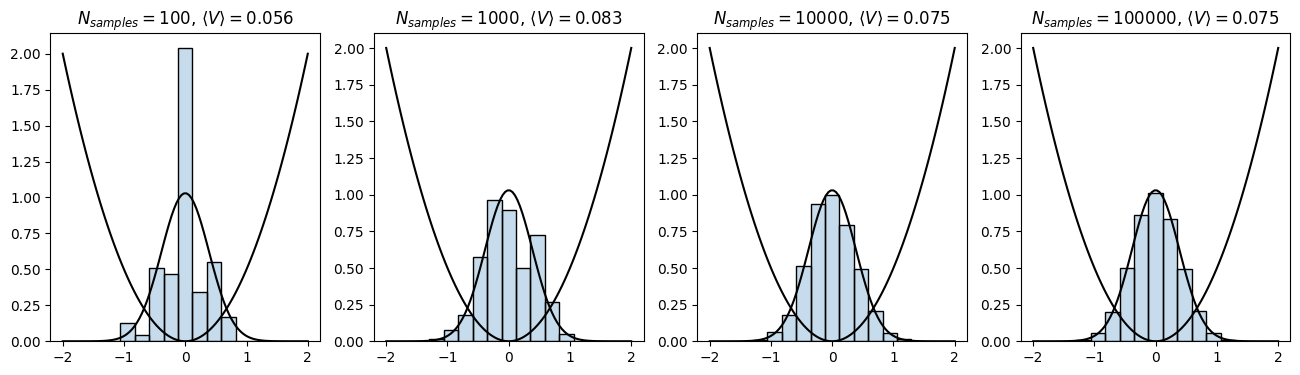

In [143]:
Nsamples = [100, 1000, 10000, 100000]
fig, axes = plt.subplots(1,4,figsize=(16,4))
for i, n in enumerate(Nsamples):
    s = System(n_samples=n)
    s.plot(axes[i])
#s.plot()

Now proposing $ x' = x + NormalDist(0,\Delta) $

This gives a local proposal.

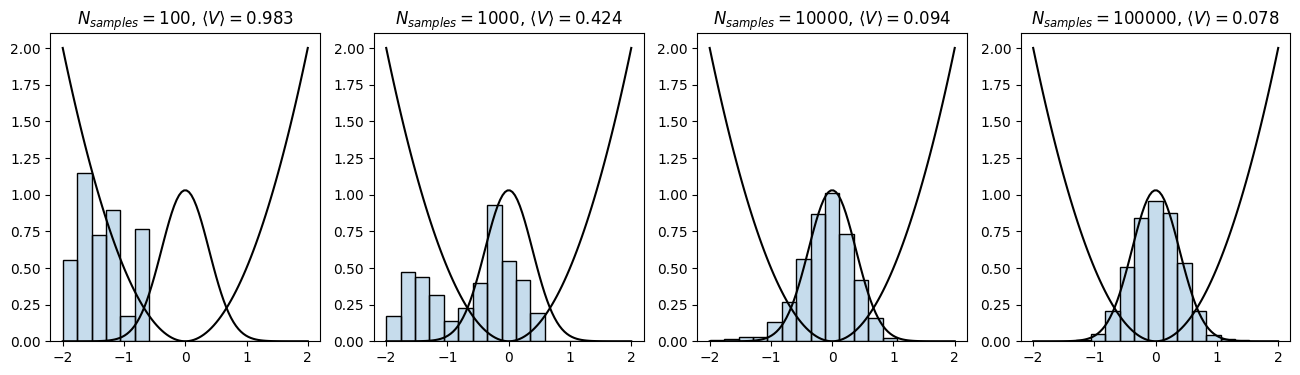

In [142]:
Nsamples = [100, 1000, 10000, 100000]
fig, axes = plt.subplots(1,4,figsize=(16,4))
for i, n in enumerate(Nsamples):
    s = System(n_samples=n, x0=-2, delta=0.05, px0=0)
    s.plot(axes[i])
#s.plot()

We see that as the number of samples increase, it migrates toward the true value.

In the first 100 samples, it appears that the position has migrated into the correct probability distribution.

With 1000 samples, the first 100 steps were used to get into the right space, the rest is now fairlt distributed.

As samples increase to 10_000 and 100_000, the first steps "vanish" in the huge amount of samples, and we get the true distribution.

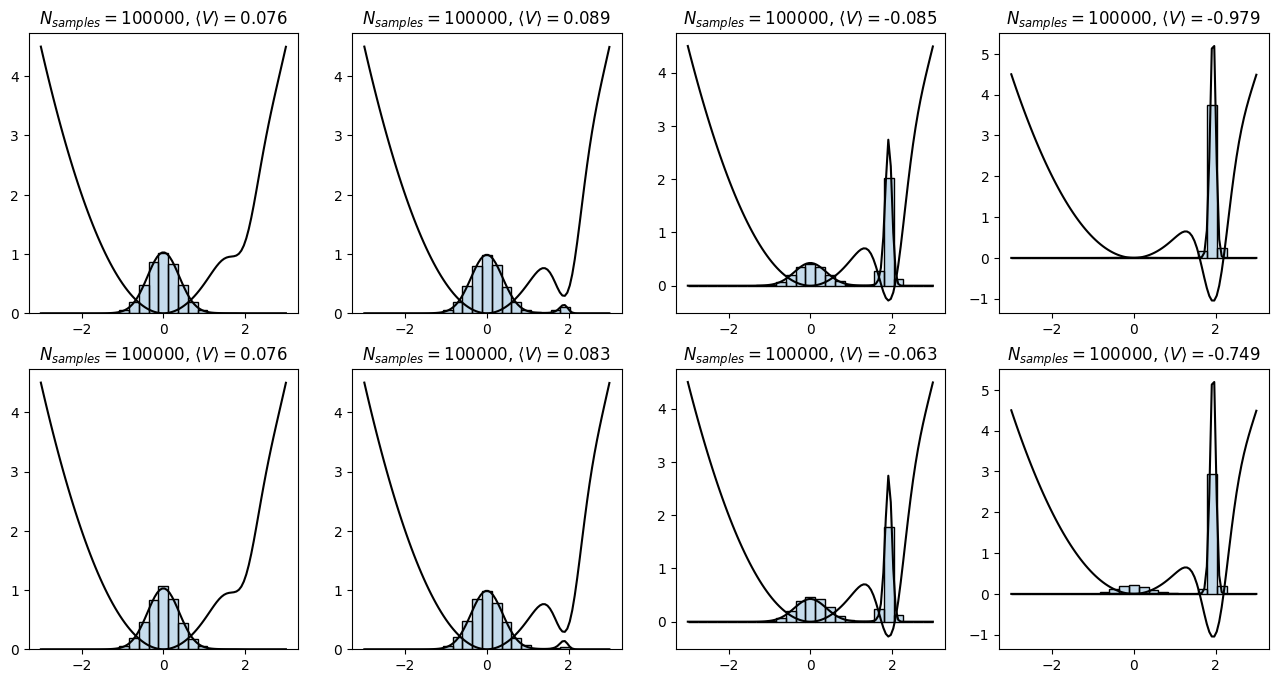

In [152]:
well_depth = [0.8, 1.6, 2.2, 3]
fig, axes = plt.subplots(2,4,figsize=(16,8))
axes = axes.flatten()
for i, A in enumerate(well_depth):
    s = System(A=A, sigma=0.3, x_well=2, xmin=-3, xmax=3)
    s.plot(axes[i])

for i, A in enumerate(well_depth):
    ax_i = i + 4
    s = System(x0=-2, delta=0.05, px0=0, A=A, sigma=0.3, x_well=2, xmin=-3, xmax=3)
    s.plot(axes[ax_i])

"Reflect about why one would not always use the global position proposal?"

With many dimensions or potentials, every position would be randomly chosen, and if the energy rise is too steep, the rejection rate is high and the state stays the same. With local proposals, closer energy regimes are explored first, and the local environment gets better representation.